In [1]:
import pandas as pd
import numpy as np

In [2]:
dataset = pd.read_csv("twitter.csv")

In [3]:
dataset

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
...,...,...,...,...,...,...,...
24778,25291,3,0,2,1,1,you's a muthaf***in lie &#8220;@LifeAsKing: @2...
24779,25292,3,0,1,2,2,"you've gone and broke the wrong heart baby, an..."
24780,25294,3,0,3,0,1,young buck wanna eat!!.. dat nigguh like I ain...
24781,25295,6,0,6,0,1,youu got wild bitches tellin you lies


In [4]:
dataset.isnull().sum()

Unnamed: 0            0
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
dtype: int64

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          24783 non-null  int64 
 1   count               24783 non-null  int64 
 2   hate_speech         24783 non-null  int64 
 3   offensive_language  24783 non-null  int64 
 4   neither             24783 non-null  int64 
 5   class               24783 non-null  int64 
 6   tweet               24783 non-null  object
dtypes: int64(6), object(1)
memory usage: 1.3+ MB


In [6]:
dataset.describe()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class
count,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000
mean,12681.192027,3.243473,0.280515,2.413711,0.549247,1.110277
std,7299.553863,0.883060,0.631851,1.399459,1.113299,0.462089
min,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,6372.500000,3.000000,0.000000,2.000000,0.000000,1.000000
50%,12703.000000,3.000000,0.000000,3.000000,0.000000,1.000000
75%,18995.500000,3.000000,0.000000,3.000000,0.000000,1.000000
max,25296.000000,9.000000,7.000000,9.000000,9.000000,2.000000


In [7]:
dataset["labels"] = dataset["class"].map({0:"Hate Speach",
                                         1:"Offensive Language",
                                         3:"No Hate or offensive language"})

In [8]:
dataset

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet,labels
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,NaN
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive Language
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive Language
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive Language
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive Language
...,...,...,...,...,...,...,...,...
24778,25291,3,0,2,1,1,you's a muthaf***in lie &#8220;@LifeAsKing: @2...,Offensive Language
24779,25292,3,0,1,2,2,"you've gone and broke the wrong heart baby, an...",NaN
24780,25294,3,0,3,0,1,young buck wanna eat!!.. dat nigguh like I ain...,Offensive Language
24781,25295,6,0,6,0,1,youu got wild bitches tellin you lies,Offensive Language


In [9]:
data = dataset[["tweet" , "labels"]]

In [10]:
data

,tweet,labels
0,!!! RT @mayasolovely: As a woman you shouldn't...,NaN
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive Language
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive Language
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive Language
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive Language
...,...,...
24778,you's a muthaf***in lie &#8220;@LifeAsKing: @2...,Offensive Language
24779,"you've gone and broke the wrong heart baby, an...",NaN
24780,young buck wanna eat!!.. dat nigguh like I ain...,Offensive Language
24781,youu got wild bitches tellin you lies,Offensive Language


In [11]:
# !pip install string

In [12]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

import nltk
nltk.download('stopwords')

stopwords = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_data(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  
    text = re.sub(r'\[.*?\]', '', text)               
    text = re.sub(r'<.*?>+', '', text)               
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)                    
    text = re.sub(r'\w*\d\w*', '', text)               
    
    words = [word for word in text.split() if word not in stopwords]
    
    stemmed_words = [stemmer.stem(word) for word in words]
    
    return " ".join(stemmed_words)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/abhimanyuredhu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [13]:
data["tweet"] = data["tweet"].apply(clean_data)

/var/folders/39/npc3ctts6k5btq927lhd19b40000gn/T/ipykernel_6888/1832165696.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["tweet"] = data["tweet"].apply(clean_data)


In [14]:
data

,tweet,labels
0,rt mayasolov woman shouldnt complain clean hou...,NaN
1,rt boy dat coldtyga dwn bad cuffin dat hoe place,Offensive Language
2,rt urkindofbrand dawg rt ever fuck bitch start...,Offensive Language
3,rt cganderson vivabas look like tranni,Offensive Language
4,rt shenikarobert shit hear might true might fa...,Offensive Language
...,...,...
24778,you muthafin lie coreyemanuel right tl trash m...,Offensive Language
24779,youv gone broke wrong heart babi drove redneck...,NaN
24780,young buck wanna eat dat nigguh like aint fuck...,Offensive Language
24781,youu got wild bitch tellin lie,Offensive Language


In [15]:
X = np.array(data["tweet"])
y = np.array(data["labels"])

In [16]:
X

array(['rt mayasolov woman shouldnt complain clean hous amp man alway take trash',
       'rt boy dat coldtyga dwn bad cuffin dat hoe place',
       'rt urkindofbrand dawg rt ever fuck bitch start cri confus shit',
       ..., 'young buck wanna eat dat nigguh like aint fuckin di',
       'youu got wild bitch tellin lie',
       'ruffl ntac eileen dahlia beauti color combin pink orang yellow amp white coll'],
      dtype=object)

In [17]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

In [18]:
cv = CountVectorizer()
X = cv.fit_transform(X)

In [19]:
X

<24783x25684 sparse matrix of type '<class 'numpy.int64'>'
	with 197849 stored elements in Compressed Sparse Row format>

In [20]:
X_train ,X_test , y_train , y_test = train_test_split(X,y, test_size = 0.33, random_state= 42)

In [21]:
X_train

<16604x25684 sparse matrix of type '<class 'numpy.int64'>'
	with 132612 stored elements in Compressed Sparse Row format>

In [22]:
from sklearn.tree import DecisionTreeClassifier

In [29]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from scipy.stats import mode

imputer_X = SimpleImputer(strategy='mean')  
X_train_clean = imputer_X.fit_transform(X_train)

y_train = pd.Series(y_train)  # Convert to Series to use isna()
if y_train.isna().any():
    most_common = y_train.mode()[0]
    y_train.fillna(most_common, inplace=True)

dt = DecisionTreeClassifier()
dt.fit(X_train_clean, y_train)


DecisionTreeClassifier()

In [35]:
y_pred = dt.predict(X_test)

In [36]:
import pandas as pd
from sklearn.metrics import confusion_matrix

y_test = pd.Series(y_test).astype(str)
y_pred = pd.Series(y_pred).astype(str)

cm = confusion_matrix(y_test, y_pred)
print(cm)


[[ 143  322    0]
 [ 236 6099    0]
 [  31 1348    0]]


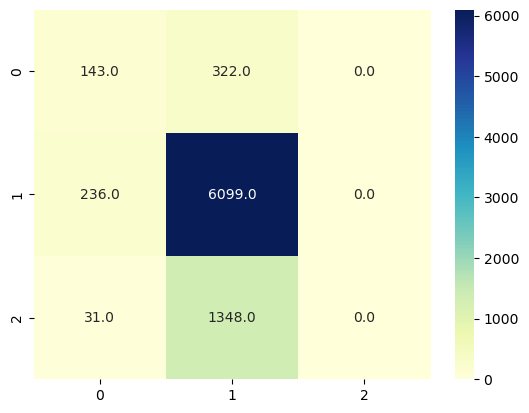

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt=".1f", cmap="YlGnBu")
plt.show()

In [39]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.763173982149407

In [40]:
sample = "Let's kill all the animals who are dangereous "
sample = clean_data(sample)

In [41]:
data1= cv.transform([sample]).toarray()

In [42]:
sample

'let kill anim danger'

In [43]:
dt.predict(data1)

array(['Offensive Language'], dtype=object)